In [1]:
!pip install -q tensorflow scikit-learn matplotlib seaborn

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [3]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/fish_dataset"

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

for root, dirs, files in os.walk(extract_path):
    print(root)

/content/fish_dataset
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food shrimp
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food black_sea_sprat
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food hourse_mackerel
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food sea_bass
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food red_sea_bream
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/animal fish bass
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food striped_red_mullet
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food red_mullet
/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test/fish sea_food gilt

In [5]:
train_dir = "/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train"
val_dir = "/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val"
test_dir = "/content/fish_dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test"

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Training Data (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test Data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


In [7]:
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)
print("Testing Images :", test_generator.samples)

print("\nNumber of Classes:", train_generator.num_classes)

print("\nClass Names:")
print(train_generator.class_indices)

Training Images : 6225
Validation Images : 1092
Testing Images : 3187

Number of Classes: 11

Class Names:
{'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}


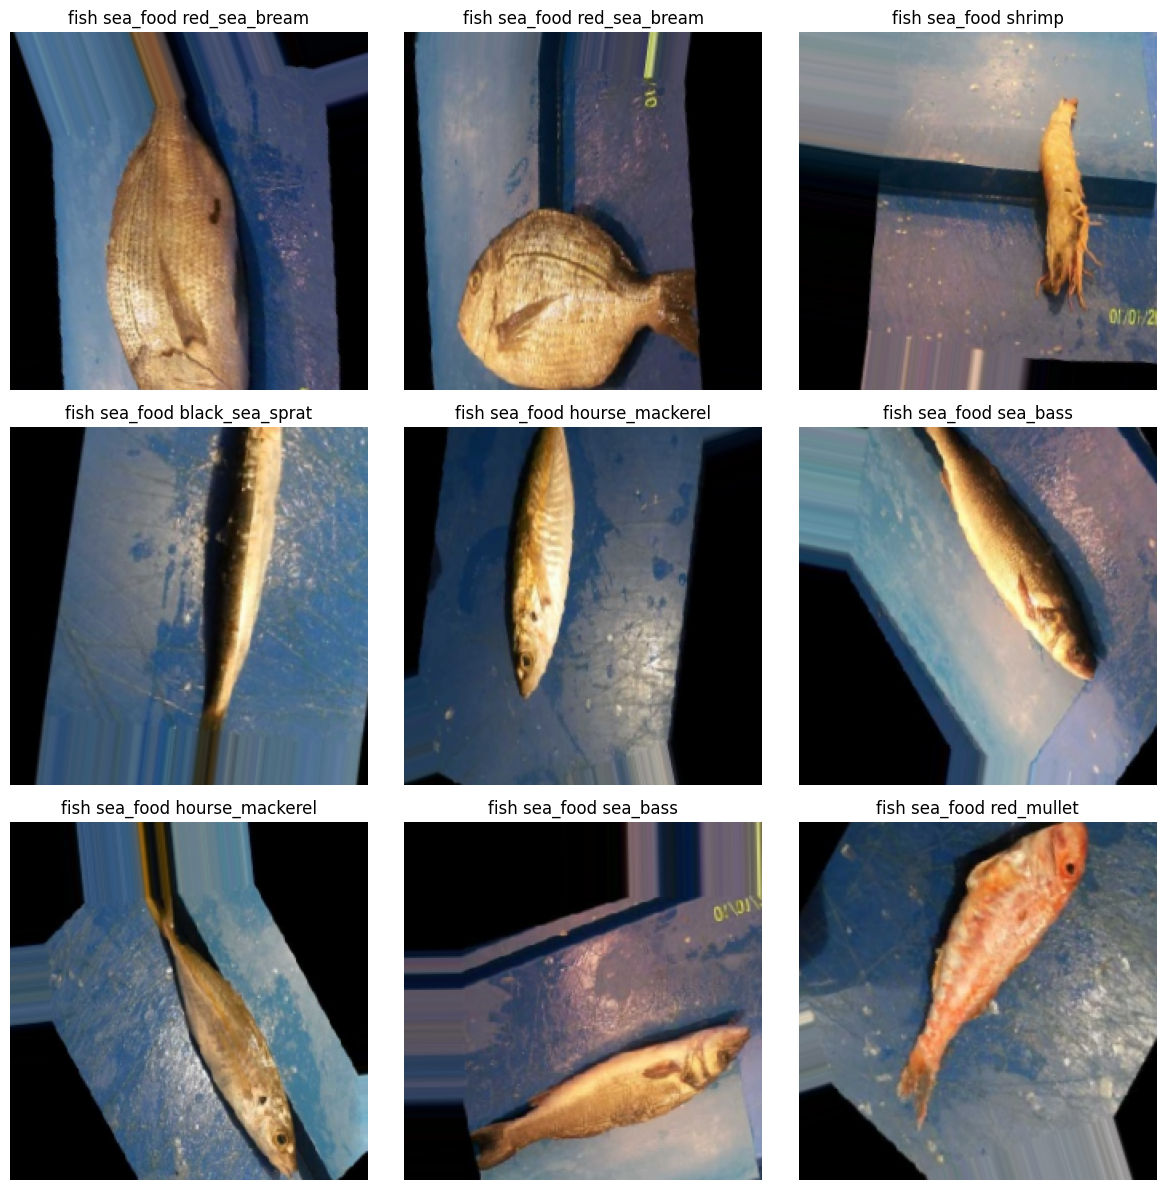

In [8]:
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation='softmax')

])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,270,859 (73.51 MB)

 Trainable params: 19,269,899 (73.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "cnn_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [12]:
EPOCHS = 20

history_cnn = cnn_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[early_stop, checkpoint]

)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.3337 - loss: 7.6649
Epoch 1: val_accuracy improved from None to 0.16758, saving model to cnn_best_model.h5



Epoch 1: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 108s 490ms/step - accuracy: 0.3941 - loss: 4.4377 - val_accuracy: 0.1676 - val_loss: 20.6797
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.4582 - loss: 1.7580
Epoch 2: val_accuracy improved from 0.16758 to 0.27106, saving model to cnn_best_model.h5



Epoch 2: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 435ms/step - accuracy: 0.4761 - loss: 1.7201 - val_accuracy: 0.2711 - val_loss: 4.1080
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5027 - loss: 1.5664
Epoch 3: val_accuracy improved from 0.27106 to 0.47527, saving model to cnn_best_model.h5



Epoch 3: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 438ms/step - accuracy: 0.5186 - loss: 1.4771 - val_accuracy: 0.4753 - val_loss: 1.5488
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.5760 - loss: 1.2044
Epoch 4: val_accuracy did not improve from 0.47527
195/195 ━━━━━━━━━━━━━━━━━━━━ 138s 419ms/step - accuracy: 0.5886 - loss: 1.1898 - val_accuracy: 0.4203 - val_loss: 2.8369
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.5964 - loss: 1.1846
Epoch 5: val_accuracy improved from 0.47527 to 0.77198, saving model to cnn_best_model.h5



Epoch 5: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 438ms/step - accuracy: 0.6040 - loss: 1.1447 - val_accuracy: 0.7720 - val_loss: 0.7032
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.6409 - loss: 1.0273
Epoch 6: val_accuracy did not improve from 0.77198
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 427ms/step - accuracy: 0.6565 - loss: 1.0000 - val_accuracy: 0.6923 - val_loss: 0.8901
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.6745 - loss: 0.9221
Epoch 7: val_accuracy did not improve from 0.77198
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 428ms/step - accuracy: 0.6792 - loss: 0.9089 - val_accuracy: 0.7674 - val_loss: 0.8590
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7147 - loss: 0.8234
Epoch 8: val_accuracy improved from 0.77198 to 0.79670, saving model to cnn_best_model.h5



Epoch 8: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 437ms/step - accuracy: 0.7015 - loss: 0.8886 - val_accuracy: 0.7967 - val_loss: 0.6035
Epoch 9/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7198 - loss: 0.8515
Epoch 9: val_accuracy improved from 0.79670 to 0.80495, saving model to cnn_best_model.h5



Epoch 9: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 429ms/step - accuracy: 0.7247 - loss: 0.8464 - val_accuracy: 0.8049 - val_loss: 0.5934
Epoch 10/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7324 - loss: 0.8213
Epoch 10: val_accuracy improved from 0.80495 to 0.85348, saving model to cnn_best_model.h5



Epoch 10: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 432ms/step - accuracy: 0.7407 - loss: 0.7787 - val_accuracy: 0.8535 - val_loss: 0.4929
Epoch 11/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.7636 - loss: 0.7166
Epoch 11: val_accuracy did not improve from 0.85348
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 423ms/step - accuracy: 0.7491 - loss: 0.7968 - val_accuracy: 0.5769 - val_loss: 1.8873
Epoch 12/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.7545 - loss: 0.7288
Epoch 12: val_accuracy did not improve from 0.85348
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 432ms/step - accuracy: 0.7611 - loss: 0.7175 - val_accuracy: 0.7830 - val_loss: 0.7305
Epoch 13/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7460 - loss: 0.8192
Epoch 13: val_accuracy did not improve from 0.85348
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 425ms/step - accuracy: 0.7531 - loss: 0.7650 - val_accuracy: 0.7573 - val_loss: 0.8390
Epoch 14/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s


Epoch 15: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 429ms/step - accuracy: 0.7791 - loss: 0.6786 - val_accuracy: 0.8947 - val_loss: 0.3356
Epoch 16/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.7767 - loss: 0.6497
Epoch 16: val_accuracy did not improve from 0.89469
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 427ms/step - accuracy: 0.7873 - loss: 0.6370 - val_accuracy: 0.7995 - val_loss: 0.5350
Epoch 17/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8223 - loss: 0.5567
Epoch 17: val_accuracy did not improve from 0.89469
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 428ms/step - accuracy: 0.8079 - loss: 0.5925 - val_accuracy: 0.8013 - val_loss: 0.7831
Epoch 18/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8217 - loss: 0.5671
Epoch 18: val_accuracy did not improve from 0.89469
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 423ms/step - accuracy: 0.8218 - loss: 0.5610 - val_accuracy: 0.7418 - val_loss: 1.2594
Epoch 19/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s


Epoch 19: finished saving model to cnn_best_model.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 428ms/step - accuracy: 0.8178 - loss: 0.5532 - val_accuracy: 0.9038 - val_loss: 0.3674
Epoch 20/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8131 - loss: 0.6180
Epoch 20: val_accuracy did not improve from 0.90385
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 421ms/step - accuracy: 0.8194 - loss: 0.5657 - val_accuracy: 0.8874 - val_loss: 0.3942


In [13]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8858 - loss: 0.3183
Test Loss : 0.3182840347290039
Test Accuracy : 0.8857859969139099


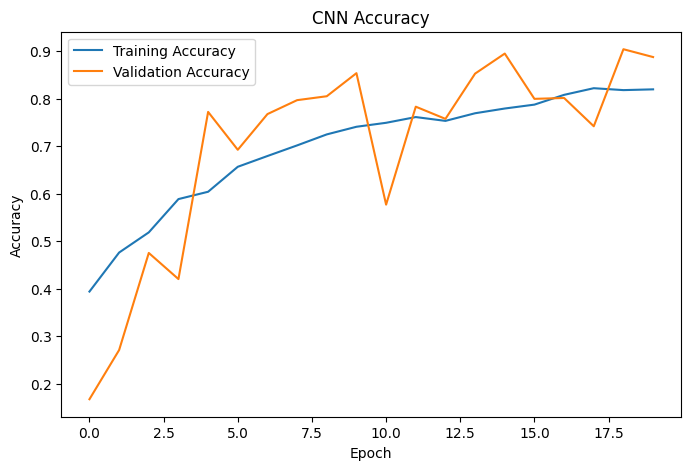

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')

plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title("CNN Accuracy")

plt.show()

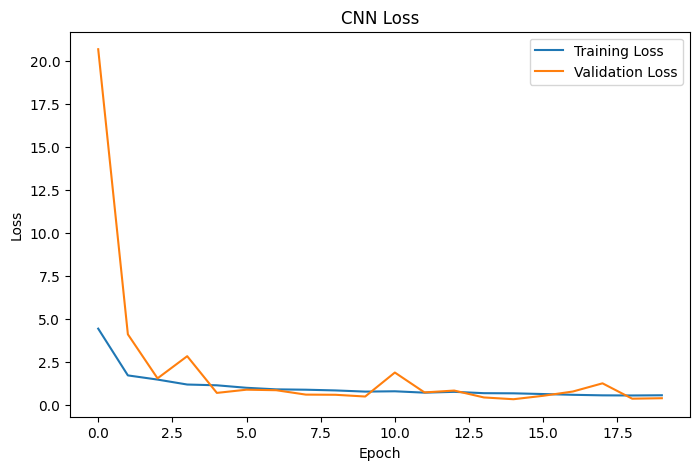

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'], label='Training Loss')

plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("CNN Loss")

plt.show()

In [16]:
predictions = cnn_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

                                  precision    recall  f1-score   support

                     animal fish       0.98      0.97      0.98       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       0.92      0.97      0.94       298
   fish sea_food gilt_head_bream       0.62      0.72      0.66       305
   fish sea_food hourse_mackerel       1.00      0.69      0.82       286
        fish sea_food red_mullet       0.99      1.00      0.99       291
     fish sea_food red_sea_bream       0.69      0.96      0.80       273
          fish sea_food sea_bass       0.81      0.67      0.73       327
            fish sea_food shrimp       0.98      1.00      0.99       289
fish sea_food striped_red_mullet       1.00      0.90      0.95       293
             fish sea_food trout       0.97      0.98      0.98       292

                        accuracy                           0.89      3187
                       macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


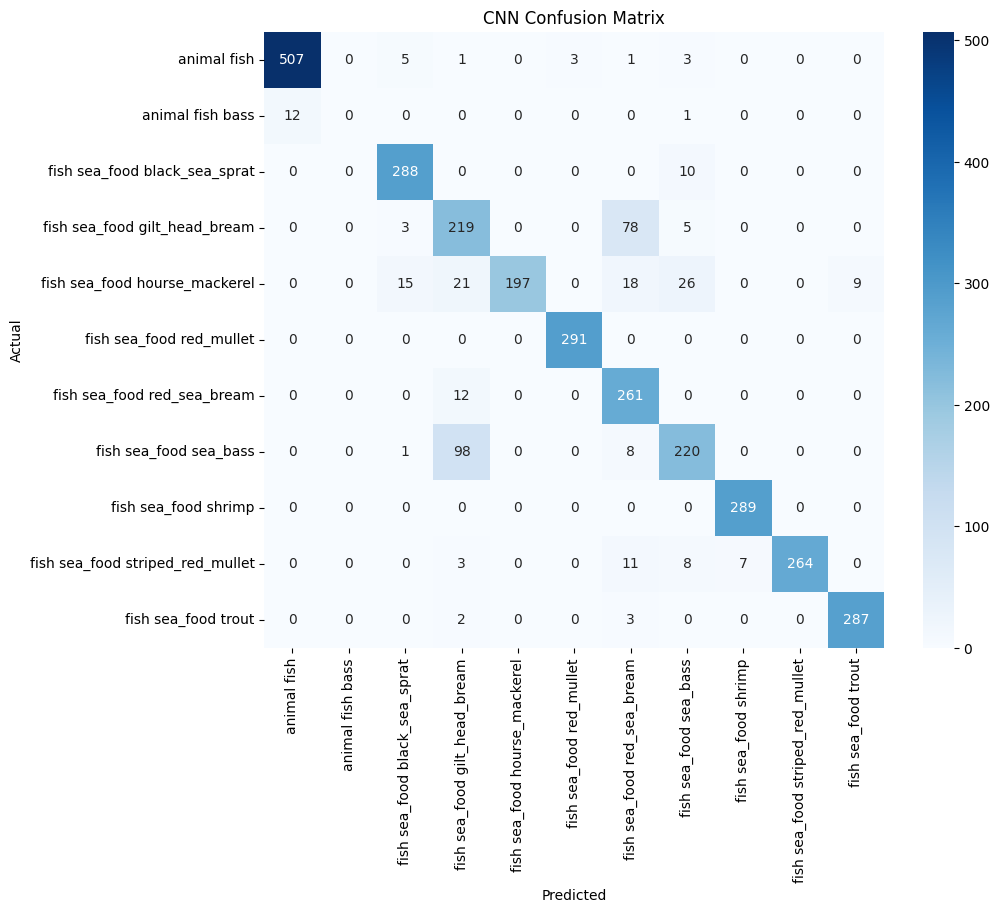

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN Confusion Matrix")

plt.show()

In [19]:
cnn_model.save("cnn_model.h5")

print("CNN Model Saved Successfully")

CNN Model Saved Successfully


In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def train_transfer_model(base_model, model_name):

    # Freeze base model
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(
        train_generator.num_classes,
        activation='softmax'
    )(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    checkpoint = ModelCheckpoint(
        f"{model_name}.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=25,
        callbacks=[checkpoint, early_stop]
    )

    loss, accuracy = model.evaluate(test_generator)

    print(f"\n{model_name}")
    print("Test Accuracy:", accuracy)
    print("Test Loss:", loss)

    return model, history, accuracy

In [23]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model, mobilenet_history, mobilenet_acc = train_transfer_model(
    mobilenet_base,
    "MobileNetV2"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6766 - loss: 1.0284
Epoch 1: val_accuracy improved from None to 0.96062, saving model to MobileNetV2.h5



Epoch 1: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 126s 545ms/step - accuracy: 0.8210 - loss: 0.5645 - val_accuracy: 0.9606 - val_loss: 0.1338
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9346 - loss: 0.1970
Epoch 2: val_accuracy improved from 0.96062 to 0.97436, saving model to MobileNetV2.h5



Epoch 2: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 409ms/step - accuracy: 0.9398 - loss: 0.1829 - val_accuracy: 0.9744 - val_loss: 0.0748
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9449 - loss: 0.1547
Epoch 3: val_accuracy did not improve from 0.97436
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 402ms/step - accuracy: 0.9518 - loss: 0.1388 - val_accuracy: 0.9744 - val_loss: 0.0672
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9571 - loss: 0.1210
Epoch 4: val_accuracy did not improve from 0.97436
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 400ms/step - accuracy: 0.9629 - loss: 0.1110 - val_accuracy: 0.9725 - val_loss: 0.0685
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9679 - loss: 0.0952
Epoch 5: val_accuracy did not improve from 0.97436
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 409ms/step - accuracy: 0.9663 - loss: 0.0999 - val_accuracy: 0.9744 - val_loss: 0.0614
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


Epoch 6: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 403ms/step - accuracy: 0.9656 - loss: 0.0905 - val_accuracy: 0.9789 - val_loss: 0.0624
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9691 - loss: 0.0928
Epoch 7: val_accuracy improved from 0.97894 to 0.98260, saving model to MobileNetV2.h5



Epoch 7: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 406ms/step - accuracy: 0.9669 - loss: 0.0939 - val_accuracy: 0.9826 - val_loss: 0.0519
Epoch 8/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9721 - loss: 0.0805
Epoch 8: val_accuracy improved from 0.98260 to 0.98718, saving model to MobileNetV2.h5



Epoch 8: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 410ms/step - accuracy: 0.9717 - loss: 0.0842 - val_accuracy: 0.9872 - val_loss: 0.0334
Epoch 9/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9696 - loss: 0.0891
Epoch 9: val_accuracy did not improve from 0.98718
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 410ms/step - accuracy: 0.9724 - loss: 0.0804 - val_accuracy: 0.9872 - val_loss: 0.0384
Epoch 10/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9778 - loss: 0.0713
Epoch 10: val_accuracy did not improve from 0.98718
195/195 ━━━━━━━━━━━━━━━━━━━━ 81s 404ms/step - accuracy: 0.9767 - loss: 0.0707 - val_accuracy: 0.9872 - val_loss: 0.0336
Epoch 11/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9693 - loss: 0.0823
Epoch 11: val_accuracy did not improve from 0.98718
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 403ms/step - accuracy: 0.9720 - loss: 0.0790 - val_accuracy: 0.9844 - val_loss: 0.0411
Epoch 12/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms


Epoch 12: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 411ms/step - accuracy: 0.9756 - loss: 0.0687 - val_accuracy: 0.9890 - val_loss: 0.0331
Epoch 13/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9781 - loss: 0.0687
Epoch 13: val_accuracy did not improve from 0.98901
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 407ms/step - accuracy: 0.9772 - loss: 0.0647 - val_accuracy: 0.9826 - val_loss: 0.0571
Epoch 14/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9722 - loss: 0.0735
Epoch 14: val_accuracy did not improve from 0.98901
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 398ms/step - accuracy: 0.9717 - loss: 0.0761 - val_accuracy: 0.9863 - val_loss: 0.0320
Epoch 15/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9800 - loss: 0.0565
Epoch 15: val_accuracy did not improve from 0.98901
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 398ms/step - accuracy: 0.9780 - loss: 0.0633 - val_accuracy: 0.9808 - val_loss: 0.0504
Epoch 16/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 39


Epoch 16: finished saving model to MobileNetV2.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 403ms/step - accuracy: 0.9810 - loss: 0.0601 - val_accuracy: 0.9918 - val_loss: 0.0278
Epoch 17/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9777 - loss: 0.0652
Epoch 17: val_accuracy did not improve from 0.99176
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 401ms/step - accuracy: 0.9806 - loss: 0.0548 - val_accuracy: 0.9918 - val_loss: 0.0253
Epoch 18/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9828 - loss: 0.0501
Epoch 18: val_accuracy did not improve from 0.99176
195/195 ━━━━━━━━━━━━━━━━━━━━ 77s 397ms/step - accuracy: 0.9794 - loss: 0.0602 - val_accuracy: 0.9817 - val_loss: 0.0497
Epoch 19/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9756 - loss: 0.0711
Epoch 19: val_accuracy did not improve from 0.99176
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 399ms/step - accuracy: 0.9775 - loss: 0.0662 - val_accuracy: 0.9863 - val_loss: 0.0408
Epoch 20/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 39

In [24]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

vgg_model, vgg_history, vgg_acc = train_transfer_model(
    vgg_base,
    "VGG16"
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.3146 - loss: 2.0255
Epoch 1: val_accuracy improved from None to 0.74634, saving model to VGG16.h5



Epoch 1: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 128s 566ms/step - accuracy: 0.4410 - loss: 1.7007 - val_accuracy: 0.7463 - val_loss: 1.1546
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.6472 - loss: 1.1619
Epoch 2: val_accuracy improved from 0.74634 to 0.82051, saving model to VGG16.h5



Epoch 2: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 493ms/step - accuracy: 0.6847 - loss: 1.0535 - val_accuracy: 0.8205 - val_loss: 0.7554
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7419 - loss: 0.8285
Epoch 3: val_accuracy improved from 0.82051 to 0.87179, saving model to VGG16.h5



Epoch 3: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 95s 488ms/step - accuracy: 0.7576 - loss: 0.7837 - val_accuracy: 0.8718 - val_loss: 0.5433
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8037 - loss: 0.6540
Epoch 4: val_accuracy improved from 0.87179 to 0.89011, saving model to VGG16.h5



Epoch 4: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 494ms/step - accuracy: 0.8137 - loss: 0.6236 - val_accuracy: 0.8901 - val_loss: 0.4225
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8459 - loss: 0.5251
Epoch 5: val_accuracy did not improve from 0.89011
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 497ms/step - accuracy: 0.8424 - loss: 0.5254 - val_accuracy: 0.8773 - val_loss: 0.4020
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8534 - loss: 0.4808
Epoch 6: val_accuracy improved from 0.89011 to 0.92399, saving model to VGG16.h5


...


Epoch 9: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 494ms/step - accuracy: 0.8935 - loss: 0.3491 - val_accuracy: 0.9460 - val_loss: 0.2196
Epoch 10/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8992 - loss: 0.3363
Epoch 10: val_accuracy improved from 0.94597 to 0.95788, saving model to VGG16.h5



Epoch 10: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 498ms/step - accuracy: 0.8998 - loss: 0.3284 - val_accuracy: 0.9579 - val_loss: 0.1903
Epoch 11/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8998 - loss: 0.3213
Epoch 11: val_accuracy did not improve from 0.95788
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 496ms/step - accuracy: 0.8991 - loss: 0.3075 - val_accuracy: 0.9478 - val_loss: 0.1935
Epoch 12/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9068 - loss: 0.2983
Epoch 12: val_accuracy did not improve from 0.95788
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 491ms/step - accuracy: 0.9049 - loss: 0.2974 - val_accuracy: 0.9496 - val_loss: 0.1901
Epoch 13/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9114 - loss: 0.2832
Epoch 13: val_accuracy did not improve from 0.95788
195/195 ━━━━━━━━━━━━━━━━━━━━ 96s 490ms/step - accuracy: 0.9129 - loss: 0.2793 - val_accuracy: 0.9487 - val_loss: 0.1756
Epoch 14/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/st


Epoch 14: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 496ms/step - accuracy: 0.9166 - loss: 0.2614 - val_accuracy: 0.9625 - val_loss: 0.1568
Epoch 15/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9222 - loss: 0.2427
Epoch 15: val_accuracy did not improve from 0.96245
195/195 ━━━━━━━━━━━━━━━━━━━━ 98s 502ms/step - accuracy: 0.9216 - loss: 0.2460 - val_accuracy: 0.9570 - val_loss: 0.1551
Epoch 16/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9166 - loss: 0.2562
Epoch 16: val_accuracy did not improve from 0.96245
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 495ms/step - accuracy: 0.9166 - loss: 0.2531 - val_accuracy: 0.9597 - val_loss: 0.1437
Epoch 17/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9282 - loss: 0.2262
Epoch 17: val_accuracy did not improve from 0.96245
195/195 ━━━━━━━━━━━━━━━━━━━━ 98s 502ms/step - accuracy: 0.9242 - loss: 0.2312 - val_accuracy: 0.9615 - val_loss: 0.1307
Epoch 18/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/st


Epoch 18: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 98s 500ms/step - accuracy: 0.9258 - loss: 0.2269 - val_accuracy: 0.9670 - val_loss: 0.1273
Epoch 19/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9307 - loss: 0.2280
Epoch 19: val_accuracy did not improve from 0.96703
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 496ms/step - accuracy: 0.9308 - loss: 0.2196 - val_accuracy: 0.9588 - val_loss: 0.1291
Epoch 20/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9323 - loss: 0.2105
Epoch 20: val_accuracy did not improve from 0.96703
195/195 ━━━━━━━━━━━━━━━━━━━━ 103s 530ms/step - accuracy: 0.9308 - loss: 0.2178 - val_accuracy: 0.9634 - val_loss: 0.1150
Epoch 21/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9274 - loss: 0.2152
Epoch 21: val_accuracy did not improve from 0.96703
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 495ms/step - accuracy: 0.9330 - loss: 0.2016 - val_accuracy: 0.9634 - val_loss: 0.1130
Epoch 22/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/s


Epoch 25: finished saving model to VGG16.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 97s 496ms/step - accuracy: 0.9375 - loss: 0.1919 - val_accuracy: 0.9725 - val_loss: 0.0974
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 298ms/step - accuracy: 0.9774 - loss: 0.0798

VGG16
Test Accuracy: 0.977408230304718
Test Loss: 0.07976503670215607


In [25]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model, resnet_history, resnet_acc = train_transfer_model(
    resnet_base,
    "ResNet50"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.1350 - loss: 2.4234
Epoch 1: val_accuracy improved from None to 0.17125, saving model to ResNet50.h5



Epoch 1: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 122s 553ms/step - accuracy: 0.1561 - loss: 2.3398 - val_accuracy: 0.1712 - val_loss: 2.2805
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.1802 - loss: 2.2791
Epoch 2: val_accuracy did not improve from 0.17125
195/195 ━━━━━━━━━━━━━━━━━━━━ 90s 460ms/step - accuracy: 0.1799 - loss: 2.2634 - val_accuracy: 0.1694 - val_loss: 2.2075
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.1766 - loss: 2.2455
Epoch 3: val_accuracy improved from 0.17125 to 0.23718, saving model to ResNet50.h5



Epoch 3: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 89s 459ms/step - accuracy: 0.1838 - loss: 2.2226 - val_accuracy: 0.2372 - val_loss: 2.1520
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.1933 - loss: 2.1938
Epoch 4: val_accuracy did not improve from 0.23718
195/195 ━━━━━━━━━━━━━━━━━━━━ 87s 446ms/step - accuracy: 0.1934 - loss: 2.1832 - val_accuracy: 0.2070 - val_loss: 2.1067
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.2040 - loss: 2.1640
Epoch 5: val_accuracy did not improve from 0.23718
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 441ms/step - accuracy: 0.2071 - loss: 2.1521 - val_accuracy: 0.2024 - val_loss: 2.0834
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2074 - loss: 2.1375
Epoch 6: val_accuracy improved from 0.23718 to 0.27289, saving model to ResNet50.h5



Epoch 6: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 89s 457ms/step - accuracy: 0.2151 - loss: 2.1290 - val_accuracy: 0.2729 - val_loss: 2.0382
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2186 - loss: 2.0954
Epoch 7: val_accuracy improved from 0.27289 to 0.28114, saving model to ResNet50.h5



Epoch 7: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 90s 459ms/step - accuracy: 0.2182 - loss: 2.1013 - val_accuracy: 0.2811 - val_loss: 2.0312
Epoch 8/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.2247 - loss: 2.0998
Epoch 8: val_accuracy improved from 0.28114 to 0.28755, saving model to ResNet50.h5


...


Epoch 10: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 88s 450ms/step - accuracy: 0.2382 - loss: 2.0675 - val_accuracy: 0.3114 - val_loss: 1.9606
Epoch 11/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.2450 - loss: 2.0546
Epoch 11: val_accuracy did not improve from 0.31136
195/195 ━━━━━━━━━━━━━━━━━━━━ 141s 447ms/step - accuracy: 0.2426 - loss: 2.0531 - val_accuracy: 0.2921 - val_loss: 1.9447
Epoch 12/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2466 - loss: 2.0422
Epoch 12: val_accuracy did not improve from 0.31136
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 443ms/step - accuracy: 0.2432 - loss: 2.0500 - val_accuracy: 0.3114 - val_loss: 1.9448
Epoch 13/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.2372 - loss: 2.0641
Epoch 13: val_accuracy did not improve from 0.31136
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 441ms/step - accuracy: 0.2467 - loss: 2.0526 - val_accuracy: 0.3013 - val_loss: 1.9347
Epoch 14/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 433m


Epoch 14: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 89s 454ms/step - accuracy: 0.2498 - loss: 2.0324 - val_accuracy: 0.3196 - val_loss: 1.9195
Epoch 15/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2489 - loss: 2.0241
Epoch 15: val_accuracy did not improve from 0.31960
195/195 ━━━━━━━━━━━━━━━━━━━━ 89s 454ms/step - accuracy: 0.2535 - loss: 2.0245 - val_accuracy: 0.2885 - val_loss: 1.9091
Epoch 16/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.2474 - loss: 2.0355
Epoch 16: val_accuracy improved from 0.31960 to 0.33608, saving model to ResNet50.h5



Epoch 16: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 89s 454ms/step - accuracy: 0.2427 - loss: 2.0276 - val_accuracy: 0.3361 - val_loss: 1.9029
Epoch 17/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.2612 - loss: 2.0123
Epoch 17: val_accuracy did not improve from 0.33608
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 439ms/step - accuracy: 0.2561 - loss: 2.0058 - val_accuracy: 0.3260 - val_loss: 1.9186
Epoch 18/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2529 - loss: 2.0198
Epoch 18: val_accuracy did not improve from 0.33608
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 437ms/step - accuracy: 0.2570 - loss: 2.0181 - val_accuracy: 0.2821 - val_loss: 1.9215
Epoch 19/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2572 - loss: 2.0220
Epoch 19: val_accuracy did not improve from 0.33608
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 441ms/step - accuracy: 0.2590 - loss: 2.0140 - val_accuracy: 0.3031 - val_loss: 1.9064
Epoch 20/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms


Epoch 22: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 440ms/step - accuracy: 0.2573 - loss: 2.0123 - val_accuracy: 0.3370 - val_loss: 1.8852
Epoch 23/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.2649 - loss: 1.9959
Epoch 23: val_accuracy did not improve from 0.33700
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 443ms/step - accuracy: 0.2623 - loss: 2.0031 - val_accuracy: 0.3361 - val_loss: 1.8805
Epoch 24/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.2654 - loss: 1.9833
Epoch 24: val_accuracy improved from 0.33700 to 0.34066, saving model to ResNet50.h5



Epoch 24: finished saving model to ResNet50.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 435ms/step - accuracy: 0.2596 - loss: 1.9928 - val_accuracy: 0.3407 - val_loss: 1.8651
Epoch 25/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.2598 - loss: 1.9779
Epoch 25: val_accuracy did not improve from 0.34066
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 432ms/step - accuracy: 0.2615 - loss: 1.9804 - val_accuracy: 0.3361 - val_loss: 1.8869
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.3386 - loss: 1.8641

ResNet50
Test Accuracy: 0.33856290578842163
Test Loss: 1.8640884160995483


In [26]:
inception_base = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

inception_model, inception_history, inception_acc = train_transfer_model(
    inception_base,
    "InceptionV3"
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.5747 - loss: 1.3746
Epoch 1: val_accuracy improved from None to 0.91667, saving model to InceptionV3.h5



Epoch 1: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 122s 538ms/step - accuracy: 0.7176 - loss: 0.8765 - val_accuracy: 0.9167 - val_loss: 0.2838
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8401 - loss: 0.4863
Epoch 2: val_accuracy improved from 0.91667 to 0.94414, saving model to InceptionV3.h5



Epoch 2: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 442ms/step - accuracy: 0.8537 - loss: 0.4402 - val_accuracy: 0.9441 - val_loss: 0.1784
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8680 - loss: 0.3867
Epoch 3: val_accuracy did not improve from 0.94414
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 425ms/step - accuracy: 0.8704 - loss: 0.3672 - val_accuracy: 0.9396 - val_loss: 0.1993
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8845 - loss: 0.3303
Epoch 4: val_accuracy improved from 0.94414 to 0.95879, saving model to InceptionV3.h5



Epoch 4: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 432ms/step - accuracy: 0.8906 - loss: 0.3141 - val_accuracy: 0.9588 - val_loss: 0.1339
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9100 - loss: 0.2770
Epoch 5: val_accuracy did not improve from 0.95879
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 430ms/step - accuracy: 0.9099 - loss: 0.2770 - val_accuracy: 0.9515 - val_loss: 0.1350
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9081 - loss: 0.2638
Epoch 6: val_accuracy improved from 0.95879 to 0.96062, saving model to InceptionV3.h5



Epoch 6: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 435ms/step - accuracy: 0.9094 - loss: 0.2593 - val_accuracy: 0.9606 - val_loss: 0.1259
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9216 - loss: 0.2365
Epoch 7: val_accuracy did not improve from 0.96062
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 433ms/step - accuracy: 0.9235 - loss: 0.2400 - val_accuracy: 0.9478 - val_loss: 0.1487
Epoch 8/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9066 - loss: 0.2745
Epoch 8: val_accuracy improved from 0.96062 to 0.97070, saving model to InceptionV3.h5


...


Epoch 10: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 435ms/step - accuracy: 0.9242 - loss: 0.2193 - val_accuracy: 0.9762 - val_loss: 0.0734
Epoch 11/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9213 - loss: 0.2166
Epoch 11: val_accuracy improved from 0.97619 to 0.97802, saving model to InceptionV3.h5



Epoch 11: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 434ms/step - accuracy: 0.9218 - loss: 0.2180 - val_accuracy: 0.9780 - val_loss: 0.0705
Epoch 12/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9273 - loss: 0.2115
Epoch 12: val_accuracy did not improve from 0.97802
195/195 ━━━━━━━━━━━━━━━━━━━━ 85s 438ms/step - accuracy: 0.9271 - loss: 0.2103 - val_accuracy: 0.9780 - val_loss: 0.0744
Epoch 13/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9316 - loss: 0.1987
Epoch 13: val_accuracy improved from 0.97802 to 0.97894, saving model to InceptionV3.h5



Epoch 13: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 433ms/step - accuracy: 0.9320 - loss: 0.2012 - val_accuracy: 0.9789 - val_loss: 0.0639
Epoch 14/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9315 - loss: 0.2006
Epoch 14: val_accuracy did not improve from 0.97894
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 426ms/step - accuracy: 0.9338 - loss: 0.1921 - val_accuracy: 0.9744 - val_loss: 0.0870
Epoch 15/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9237 - loss: 0.2181
Epoch 15: val_accuracy did not improve from 0.97894
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 427ms/step - accuracy: 0.9314 - loss: 0.2012 - val_accuracy: 0.9725 - val_loss: 0.0734
Epoch 16/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9338 - loss: 0.1835
Epoch 16: val_accuracy improved from 0.97894 to 0.98168, saving model to InceptionV3.h5



Epoch 16: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 428ms/step - accuracy: 0.9380 - loss: 0.1772 - val_accuracy: 0.9817 - val_loss: 0.0559
Epoch 17/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9286 - loss: 0.2004
Epoch 17: val_accuracy did not improve from 0.98168
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 420ms/step - accuracy: 0.9332 - loss: 0.1901 - val_accuracy: 0.9652 - val_loss: 0.0818
Epoch 18/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9297 - loss: 0.1918
Epoch 18: val_accuracy did not improve from 0.98168
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 424ms/step - accuracy: 0.9324 - loss: 0.1922 - val_accuracy: 0.9707 - val_loss: 0.0870
Epoch 19/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9467 - loss: 0.1630
Epoch 19: val_accuracy did not improve from 0.98168
195/195 ━━━━━━━━━━━━━━━━━━━━ 86s 440ms/step - accuracy: 0.9409 - loss: 0.1765 - val_accuracy: 0.9744 - val_loss: 0.0676
Epoch 20/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 42


Epoch 23: finished saving model to InceptionV3.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 91s 468ms/step - accuracy: 0.9391 - loss: 0.1813 - val_accuracy: 0.9881 - val_loss: 0.0442
Epoch 24/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9444 - loss: 0.1680
Epoch 24: val_accuracy did not improve from 0.98810
195/195 ━━━━━━━━━━━━━━━━━━━━ 87s 446ms/step - accuracy: 0.9439 - loss: 0.1661 - val_accuracy: 0.9826 - val_loss: 0.0476
Epoch 25/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9374 - loss: 0.1832
Epoch 25: val_accuracy did not improve from 0.98810
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 423ms/step - accuracy: 0.9388 - loss: 0.1752 - val_accuracy: 0.9799 - val_loss: 0.0655
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.9912 - loss: 0.0379

InceptionV3
Test Accuracy: 0.9912143349647522
Test Loss: 0.03786547854542732


In [27]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "CNN",
        "MobileNetV2",
        "VGG16",
        "ResNet50",
        "InceptionV3"
    ],
    "Accuracy": [
        test_accuracy,
        mobilenet_acc,
        vgg_acc,
        resnet_acc,
        inception_acc,
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy
0,MobileNetV2,0.994352
1,InceptionV3,0.991214
2,VGG16,0.977408
3,CNN,0.885786
4,ResNet50,0.338563


In [28]:
results.to_csv("model_comparison.csv", index=False)

print(results)

         Model  Accuracy
0  MobileNetV2  0.994352
1  InceptionV3  0.991214
2        VGG16  0.977408
3          CNN  0.885786
4     ResNet50  0.338563


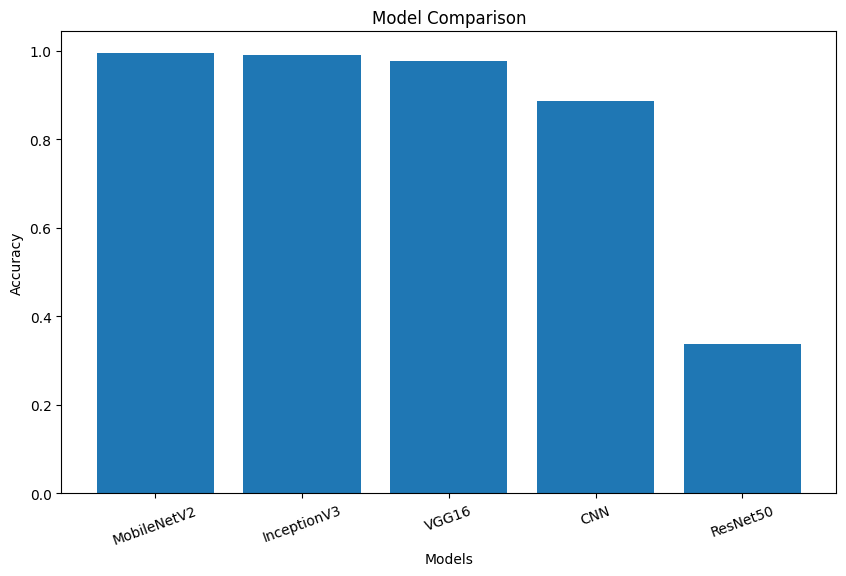

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [30]:
best_model = results.iloc[0]["Model"]

print("Best Model:", best_model)

Best Model: MobileNetV2


In [31]:
results.to_csv("model_comparison.csv", index=False)

In [32]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import accuracy_score

In [37]:
def evaluate_model(model, model_name):

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=list(test_generator.class_indices.keys()),
        yticklabels=list(test_generator.class_indices.keys())
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy, precision, recall, f1

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
MobileNetV2
Accuracy : 0.9943520552243489
Precision: 0.9943989979942817
Recall   : 0.9943520552243489
F1 Score : 0.9941715364081369

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.62      0.76        13
   fish sea_food black_sea_sprat       1.00      0.99      0.99       298
   fish sea_food gilt_head_bream       1.00      0.99      0.99       305
   fish sea_food hourse_mackerel       1.00      0.99      0.99       286
        fish sea_food red_mullet       1.00      0.99      0.99       291
     fish sea_food red_sea_bream       0.99      1.00      0.99       273
          fish sea_food sea_bass       0.99      1.00      0.99       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.99      1.00      0.

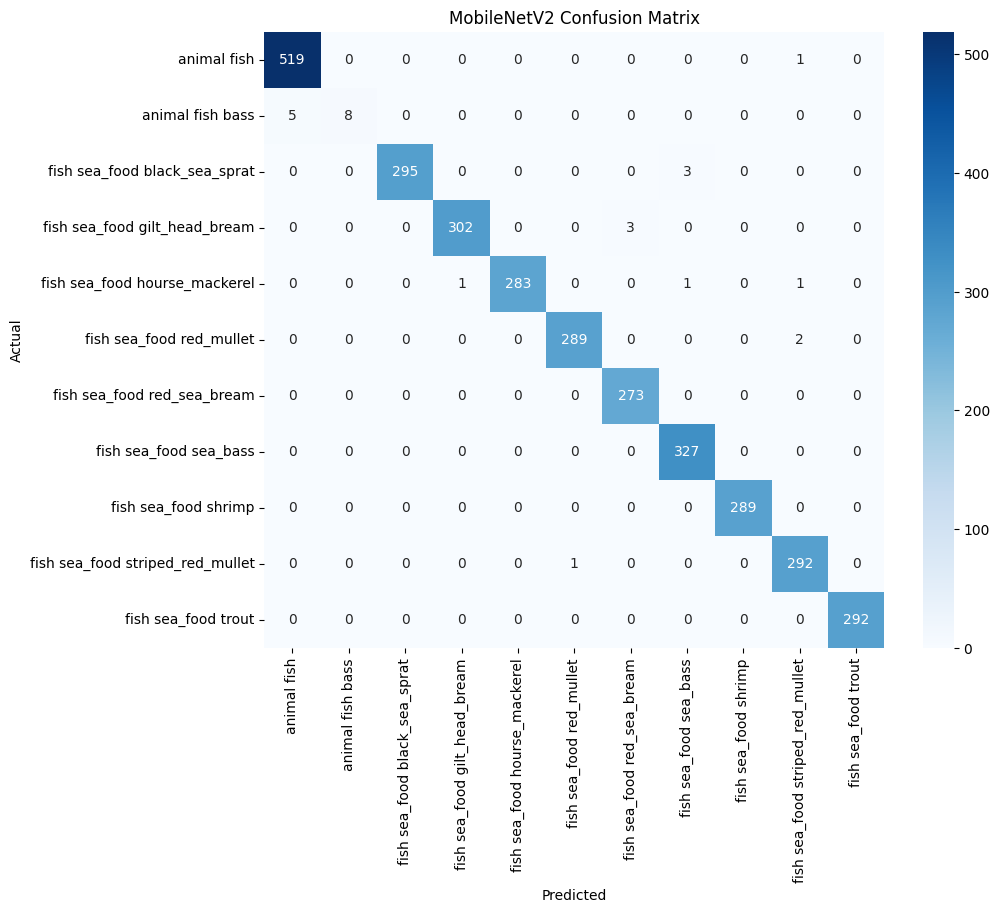

In [38]:
mobilenet_metrics = evaluate_model(
    mobilenet_model,
    "MobileNetV2"
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step
CNN
Accuracy : 0.8857860056479447
Precision: 0.8955200372903696
Recall   : 0.8857860056479447
F1 Score : 0.8848937059817291

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.98      0.97      0.98       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       0.92      0.97      0.94       298
   fish sea_food gilt_head_bream       0.62      0.72      0.66       305
   fish sea_food hourse_mackerel       1.00      0.69      0.82       286
        fish sea_food red_mullet       0.99      1.00      0.99       291
     fish sea_food red_sea_bream       0.69      0.96      0.80       273
          fish sea_food sea_bass       0.81      0.67      0.73       327
            fish sea_food shrimp       0.98      1.00      0.99       289
fish sea_food striped_red_mullet       1.00      0.90      0.95      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

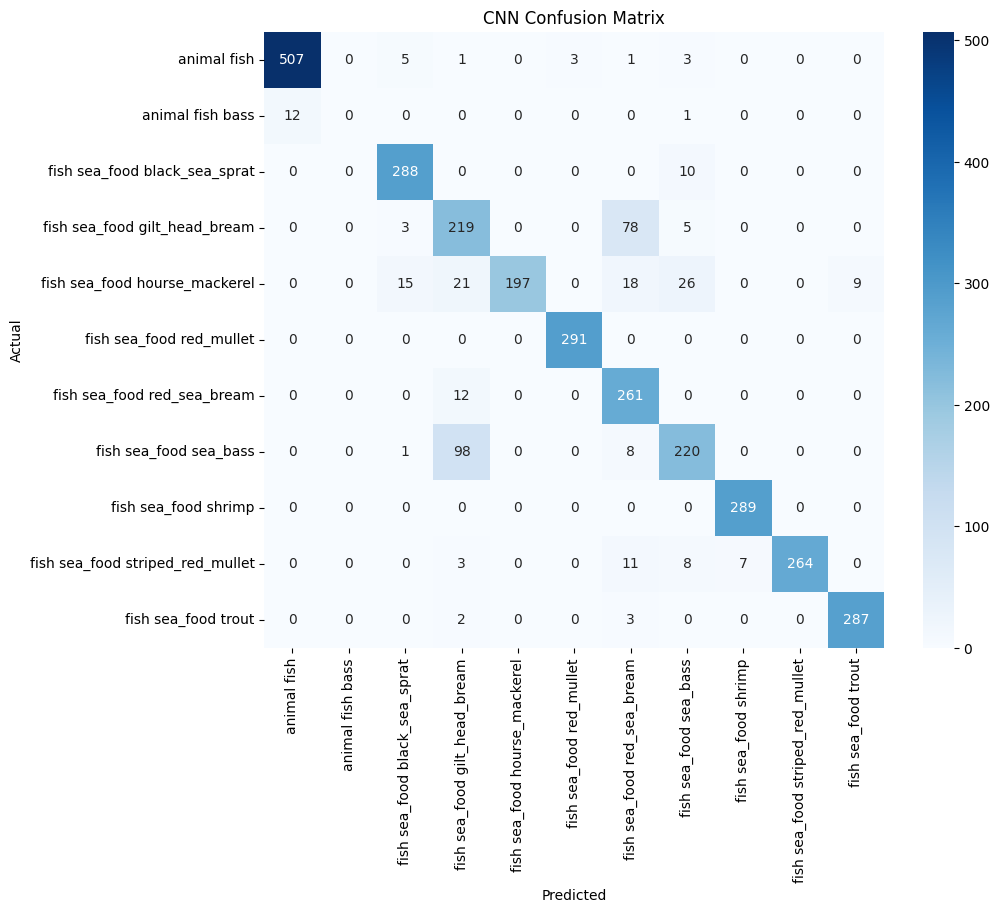

In [39]:
cnn_metrics = evaluate_model(
    cnn_model,
    "CNN"
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step
ResNet50
Accuracy : 0.33856291182930653
Precision: 0.3559988896461204
Recall   : 0.33856291182930653
F1 Score : 0.25892056039221434

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.48      0.72      0.58       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       0.14      0.00      0.01       298
   fish sea_food gilt_head_bream       0.16      0.02      0.04       305
   fish sea_food hourse_mackerel       0.28      0.62      0.38       286
        fish sea_food red_mullet       0.25      0.47      0.33       291
     fish sea_food red_sea_bream       0.48      0.04      0.07       273
          fish sea_food sea_bass       0.79      0.05      0.09       327
            fish sea_food shrimp       0.33      0.56      0.42       289
fish sea_food striped_red_mullet       0.22      0.03      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

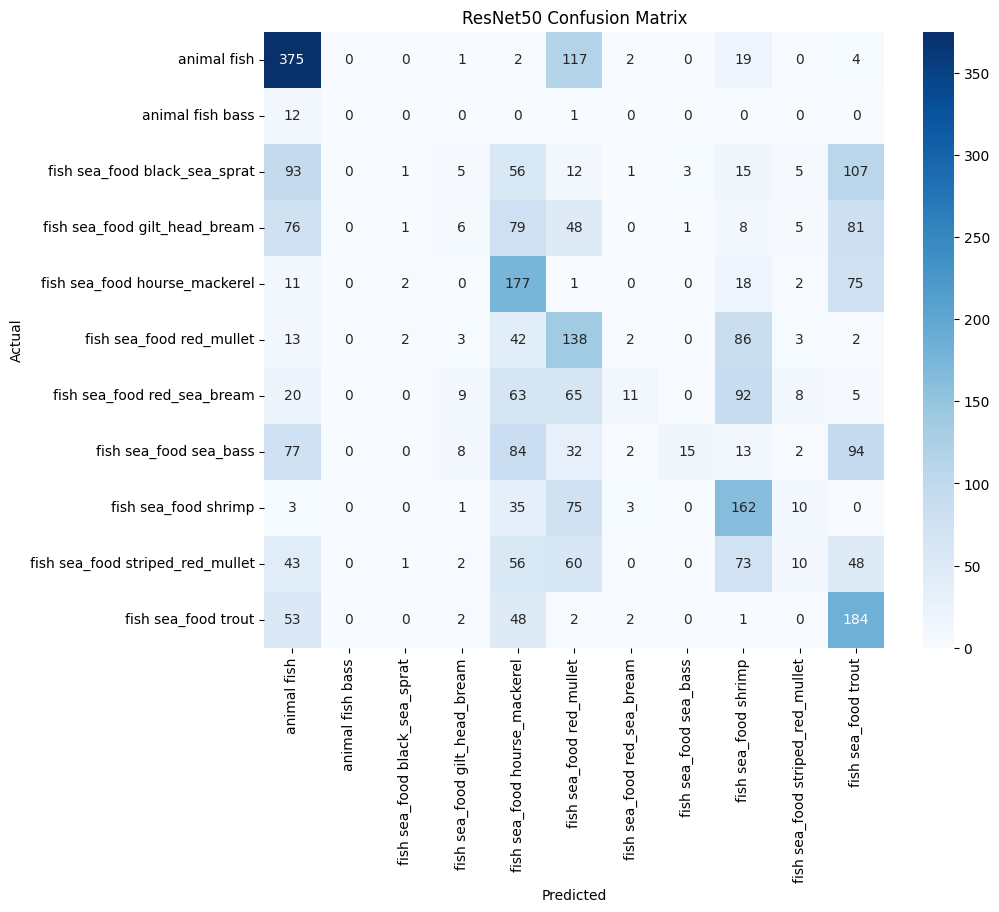

In [40]:
resnet_metrics = evaluate_model(
    resnet_model,
    "ResNet50"
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 215ms/step
VGG16
Accuracy : 0.9774082208973957
Precision: 0.9771238769978929
Recall   : 0.9774082208973957
F1 Score : 0.9766608203679527

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.98      0.99      0.98       520
                animal fish bass       0.80      0.31      0.44        13
   fish sea_food black_sea_sprat       0.99      1.00      0.99       298
   fish sea_food gilt_head_bream       0.96      1.00      0.98       305
   fish sea_food hourse_mackerel       0.98      0.99      0.98       286
        fish sea_food red_mullet       0.96      0.96      0.96       291
     fish sea_food red_sea_bream       1.00      0.98      0.99       273
          fish sea_food sea_bass       1.00      0.99      1.00       327
            fish sea_food shrimp       0.95      1.00      0.98       289
fish sea_food striped_red_mullet       0.96      0.91      0.93  

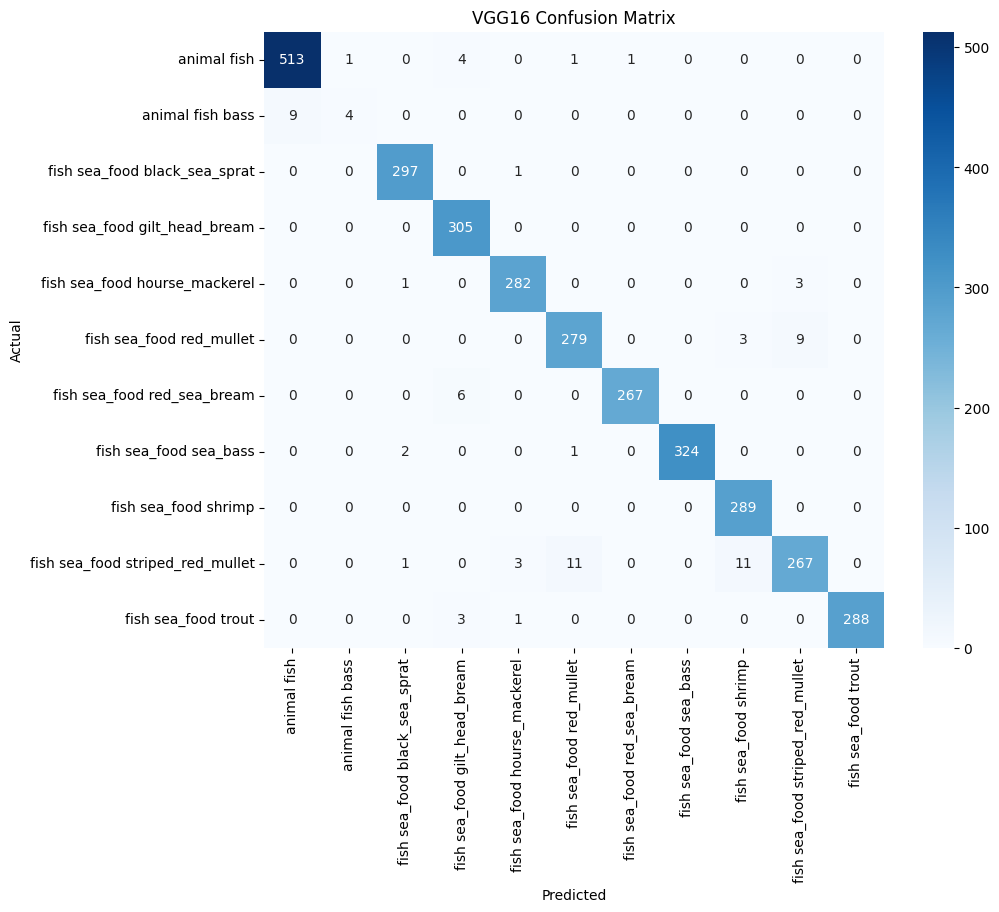

In [41]:
vgg_metrics = evaluate_model(
    vgg_model,
    "VGG16"
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step
MobileNetV2
Accuracy : 0.9943520552243489
Precision: 0.9943989979942817
Recall   : 0.9943520552243489
F1 Score : 0.9941715364081369

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.62      0.76        13
   fish sea_food black_sea_sprat       1.00      0.99      0.99       298
   fish sea_food gilt_head_bream       1.00      0.99      0.99       305
   fish sea_food hourse_mackerel       1.00      0.99      0.99       286
        fish sea_food red_mullet       1.00      0.99      0.99       291
     fish sea_food red_sea_bream       0.99      1.00      0.99       273
          fish sea_food sea_bass       0.99      1.00      0.99       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.99      1.00      0.

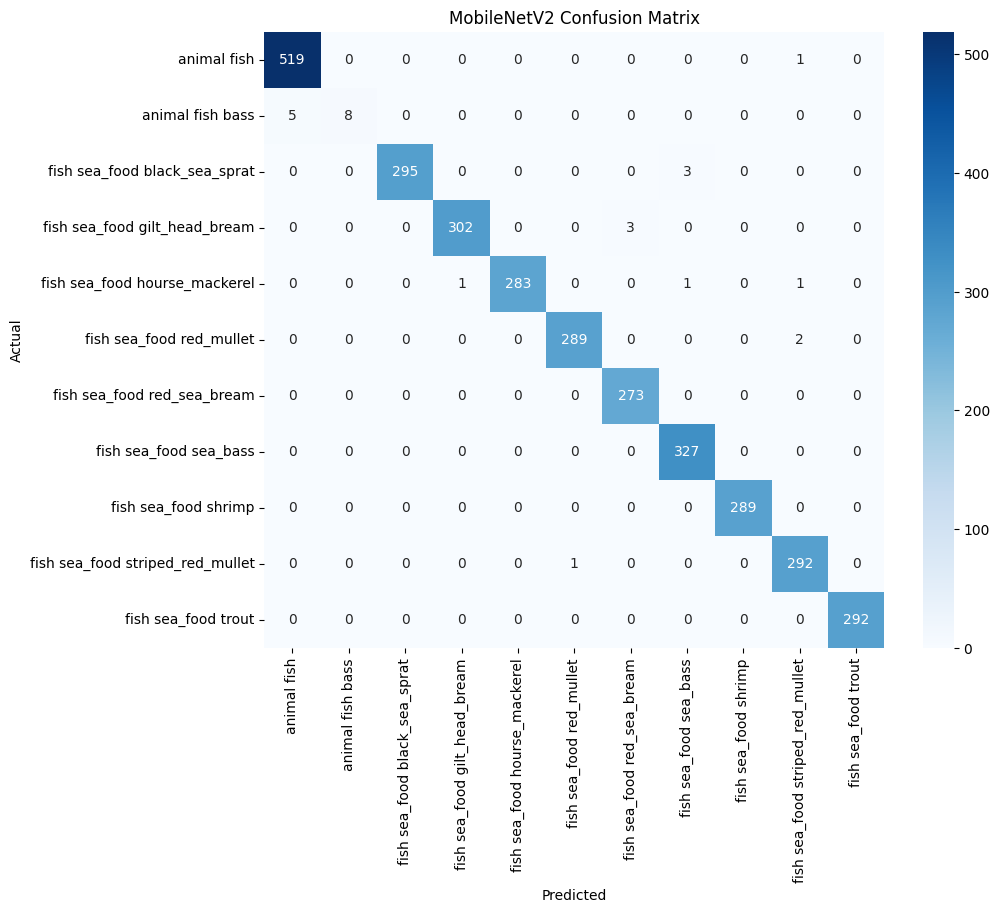

In [42]:
mobilenet_metrics = evaluate_model(
    mobilenet_model,
    "MobileNetV2"
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step
InceptionV3
Accuracy : 0.991214308126765
Precision: 0.9912891447614852
Recall   : 0.991214308126765
F1 Score : 0.990936738110362

Classification Report

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.54      0.70        13
   fish sea_food black_sea_sprat       0.99      1.00      0.99       298
   fish sea_food gilt_head_bream       0.99      1.00      0.99       305
   fish sea_food hourse_mackerel       0.99      1.00      1.00       286
        fish sea_food red_mullet       1.00      0.98      0.99       291
     fish sea_food red_sea_bream       1.00      0.99      1.00       273
          fish sea_food sea_bass       0.99      0.98      0.98       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.97      0.99      0.9

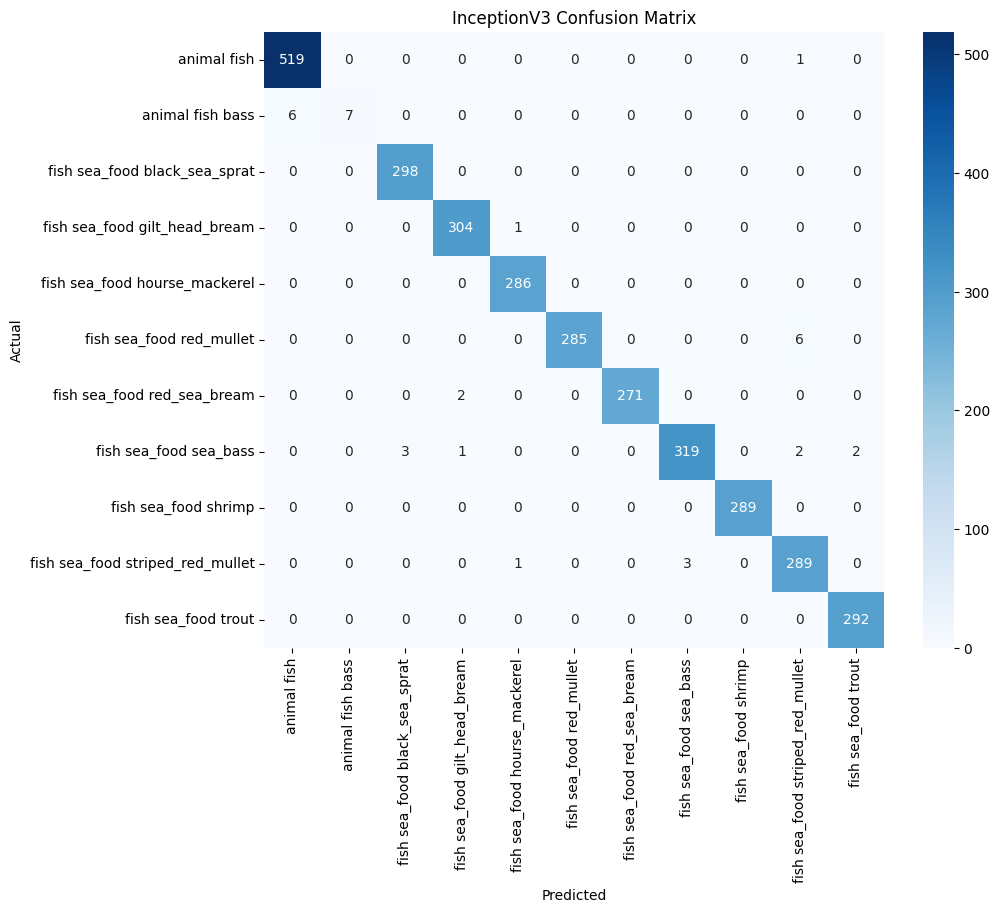

In [43]:
inception_metrics = evaluate_model(
    inception_model,
    "InceptionV3"
)

In [44]:
comparison = pd.DataFrame({

    "Model":[
        "CNN",
        "MobileNetV2",
        "VGG16",
        "ResNet50",
        "InceptionV3"
    ],

    "Accuracy":[
        cnn_metrics[0],
        mobilenet_metrics[0],
        vgg_metrics[0],
        resnet_metrics[0],
        inception_metrics[0]
    ],

    "Precision":[
        cnn_metrics[1],
        mobilenet_metrics[1],
        vgg_metrics[1],
        resnet_metrics[1],
        inception_metrics[1]
    ],

    "Recall":[
        cnn_metrics[2],
        mobilenet_metrics[2],
        vgg_metrics[2],
        resnet_metrics[2],
        inception_metrics[2]
    ],

    "F1 Score":[
        cnn_metrics[3],
        mobilenet_metrics[3],
        vgg_metrics[3],
        resnet_metrics[3],
        inception_metrics[3]
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.885786,0.895520,0.885786,0.884894
1,MobileNetV2,0.994352,0.994399,0.994352,0.994172
2,VGG16,0.977408,0.977124,0.977408,0.976661
3,ResNet50,0.338563,0.355999,0.338563,0.258921
4,InceptionV3,0.991214,0.991289,0.991214,0.990937


In [45]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2,0.994352,0.994399,0.994352,0.994172
1,InceptionV3,0.991214,0.991289,0.991214,0.990937
2,VGG16,0.977408,0.977124,0.977408,0.976661
3,CNN,0.885786,0.895520,0.885786,0.884894
4,ResNet50,0.338563,0.355999,0.338563,0.258921


In [46]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2,0.994352,0.994399,0.994352,0.994172
1,InceptionV3,0.991214,0.991289,0.991214,0.990937
2,VGG16,0.977408,0.977124,0.977408,0.976661
3,CNN,0.885786,0.895520,0.885786,0.884894
4,ResNet50,0.338563,0.355999,0.338563,0.258921


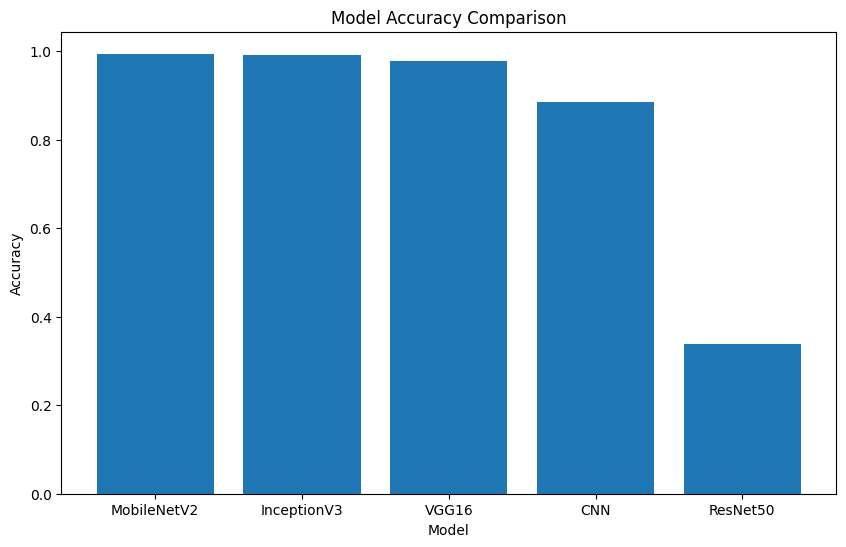

In [47]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [48]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

if best_model_name == "CNN":
    cnn_model.save("best_fish_classifier.h5")

elif best_model_name == "MobileNetV2":
    mobilenet_model.save("best_fish_classifier.h5")

elif best_model_name == "VGG16":
    vgg_model.save("best_fish_classifier.h5")

elif best_model_name == "ResNet50":
    resnet_model.save("best_fish_classifier.h5")

elif best_model_name == "InceptionV3":
    inception_model.save("best_fish_classifier.h5")

print("Best model saved successfully!")

Best Model: MobileNetV2
Best model saved successfully!


In [49]:
from google.colab import files

files.download("best_fish_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
import json

class_indices = train_generator.class_indices

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>